# Capstone Project\-Heatwave in Europe

Author: Md Humayain Kabir


--------------



<span style='font-size:x-large'>Heatwave and mortality in Europpe Analysis Capstone Project</span>

Author: Md Humayain Kabir

Date: 29 March 2026

\#\# Environmental Research Question: 

1. How did heatwave evolve across Europe during 2000\-2023?
2. Who is most vulnerable, and what were the measurable health impacts \(excess mortality\)? 

Link to GitHub repository: [GitHub Repository](insert%20link%20here) 



## Loading Data

Data sources: Extreme Heatwave days data: [https://cds.climate.copernicus.eu/datasets/sis\-ecde\-climate\-indicators?tab=download](https://cds.climate.copernicus.eu/datasets/sis-ecde-climate-indicators?tab=download) 

Deaths by week and sex in the Europe: [https://ec.europa.eu/eurostat/databrowser/view/demo\_r\_mwk\_ts\_\_custom\_20693352/default/table](https://ec.europa.eu/eurostat/databrowser/view/demo_r_mwk_ts__custom_20693352/default/table) 


In [3]:
# Load libraries

library(readxl)
library(dplyr)
library(tidyr)
library(stringr)
library(ggplot2)
library(ISOweek)
library(forcats)
library(sf)
library(terra)
library(exactextractr)
library(rnaturalearth)
library(lubridate)
library(ggrepel)
library(broom)


Attaching package: ‘dplyr’




The following objects are masked from ‘package:stats’:

    filter, lag




The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union




Linking to GEOS 3.12.1, GDAL 3.8.4, PROJ 9.4.0; sf_use_s2() is TRUE



terra 1.8.86




Attaching package: ‘terra’




The following object is masked from ‘package:tidyr’:

    extract





Attaching package: ‘lubridate’




The following objects are masked from ‘package:terra’:

    intersect, union




The following objects are masked from ‘package:base’:

    date, intersect, setdiff, union




In [4]:
# Read the raw data

utci_file <- "10_high_utci_days-reanalysis-monthly-grid-1940-2023-v1.0.nc"
utci_full <- rast(utci_file, subds = "high_utci_days")
utci_full

Warning message in min(rs):
“no non-missing arguments to min; returning Inf”


Warning message in max(rs):
“no non-missing arguments to max; returning -Inf”


Warning message in min(rs):
“no non-missing arguments to min; returning Inf”


Warning message:
“[rast] cells are not equally spaced; extent is not defined”


class       : SpatRaster 
size        : 271, 1, 186480  (nrow, ncol, nlyr)
resolution  : 1, 1  (x, y)
extent      : 0, 1, 0, 271  (xmin, xmax, ymin, ymax)
coord. ref. :  
source      : 10_high_utci_days-reanalysis-monthly-grid-1940-2023-v1.0.nc 
varname     : high_utci_days 
names       : high_~6.5_1, high_~.75_1, high_~=27_1, high_~.25_1, high_~7.5_1, high_~.75_1, ... 
unit        : 1 
depth       : 26.5 to 72.5 (lat [degrees_north]: 185 steps) 
time (days) : 1940-01-01 to 2023-12-01 (1008 steps) 

In [5]:
#Read UTCI NetCDF for 2000–2023

all_time_vals <- seq(as.Date("1940-01-01"), as.Date("2023-12-01"), by = "month")
time(utci_full) <- all_time_vals

ERROR: Error: [time<-] length(value) != nlyr(x)


In [6]:

#Select only 2000–2023
utci <- utci_full[[which(time(utci_full) >= as.Date("2000-01-01") &
                         time(utci_full) <= as.Date("2023-12-01"))]]

utci

class       : SpatRaster 
size        : 271, 1, 53280  (nrow, ncol, nlyr)
resolution  : 1, 1  (x, y)
extent      : 0, 1, 0, 271  (xmin, xmax, ymin, ymax)
coord. ref. :  
source      : 10_high_utci_days-reanalysis-monthly-grid-1940-2023-v1.0.nc 
varname     : high_utci_days 
names       : high_~5_721, high_~5_721, high_~7_721, high_~5_721, high_~5_721, high_~5_721, ... 
unit        : 1 
depth       : 26.5 to 72.5 (lat [degrees_north]: 185 steps) 
time (days) : 2000-01-01 to 2023-12-01 (288 steps) 

In [7]:
#Build Europe-wide UTCI annual and summer series

utci_europe_df <- data.frame(
  date = time(utci),
  year = year(time(utci)),
  month = month(time(utci)),
  europe_mean_utci_days = global(utci, fun = "mean", na.rm = TRUE)[,1]
)

utci_annual_europe <- utci_europe_df |>
  group_by(year) |>
  summarise(
    annual_utci_days = sum(europe_mean_utci_days, na.rm = TRUE),
    .groups = "drop"
  )

utci_summer_europe <- utci_europe_df |>
  filter(month %in% c(6, 7, 8)) |>
  group_by(year) |>
  summarise(
    summer_utci_days = sum(europe_mean_utci_days, na.rm = TRUE),
    .groups = "drop"
  )

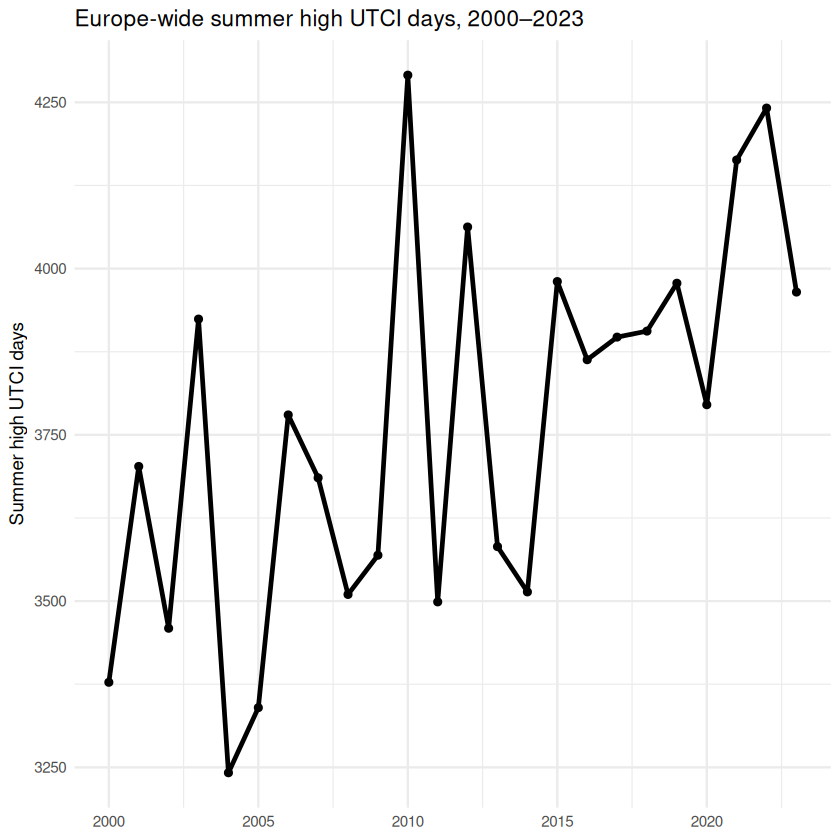

In [8]:
# Europe-wide summer UTCI trend

ggplot(utci_summer_europe, aes(x = year, y = summer_utci_days)) +
  geom_line(linewidth = 1) +
  geom_point() +
  labs(
    title = "Europe-wide summer high UTCI days, 2000–2023",
    x = NULL,
    y = "Summer high UTCI days"
  ) +
  theme_minimal()

## Ethical Considerations

- Privacy: The dataset does not contain personal data.
- Governance: Data used is openly available and ethically sourced.
- Bias: Consideration of potential biases in dataset and analysis.

